# Load libraries

In [32]:
%reload_ext autoreload
%autoreload 2

import py4DSTEM
import numpy as np
import matplotlib.pyplot as plt
import h5py
from py4DSTEM import show
from modules_generate_synthethic_4DSTEM import generate_random_colormap
import helper_function   as hf
from sklearn import cluster
from scipy.signal import fftconvolve
from scipy.spatial import distance
from scipy.ndimage import binary_dilation
from skimage.transform import AffineTransform, warp
from matplotlib.colors import ListedColormap, BoundaryNorm

print(py4DSTEM.__version__)
%autoreload 2


0.14.8


# Define custom functions

# Load data

# check output

In [2]:
saved_file_path = "./"
num_grains = 60
syn_2D_scanSpace_map_side_dimension = 128
syn_2D_scanSpace_map = np.load(saved_file_path + "syn_2D_scanSpace_map_side_dim%d_numGrains%d.npy"%(syn_2D_scanSpace_map_side_dimension, num_grains))
custom_cmap = generate_random_colormap(num_colors=num_grains, background_color=(0, 0, 0))


In [46]:
new_4d_tot = np.load(saved_file_path + "multi_crystal_synthetic_4DSTEM_data.npy")
class_label = np.load(saved_file_path + "multi_crystal_synthetic_4DSTEM_data_crystalClass_labels.npy")





In [4]:
datacube_aligned_data = py4DSTEM.DataCube(new_4d_tot)

In [5]:
datacube_aligned_data.get_dp_max()
datacube_aligned_data.get_dp_mean()
dp_mean = datacube_aligned_data.get_dp_mean()
dp_max = datacube_aligned_data.get_dp_max()


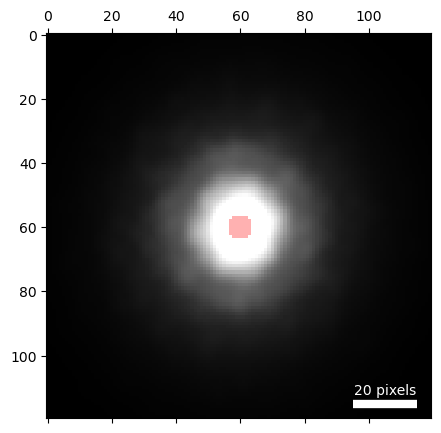

In [6]:
# set the geometry by hand
center = (60,60)
radius = 4


# overlay selected detector position over mean dp
datacube_aligned_data.position_detector(
    mode = 'circle',
    geometry = (
        center,
        radius
    )
)

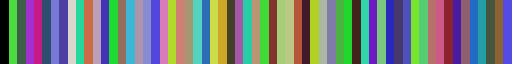

In [25]:
custom_cmap

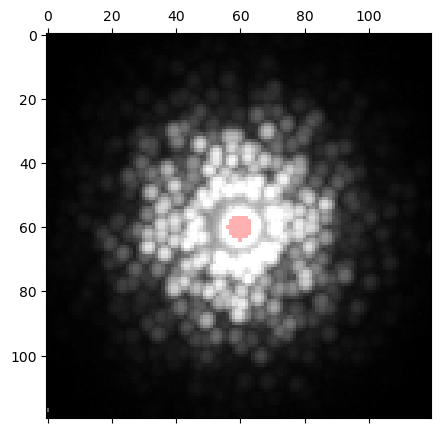

100%|██████████████████████████████████| 16384/16384 [00:00<00:00, 75713.68it/s]










virtual bright field










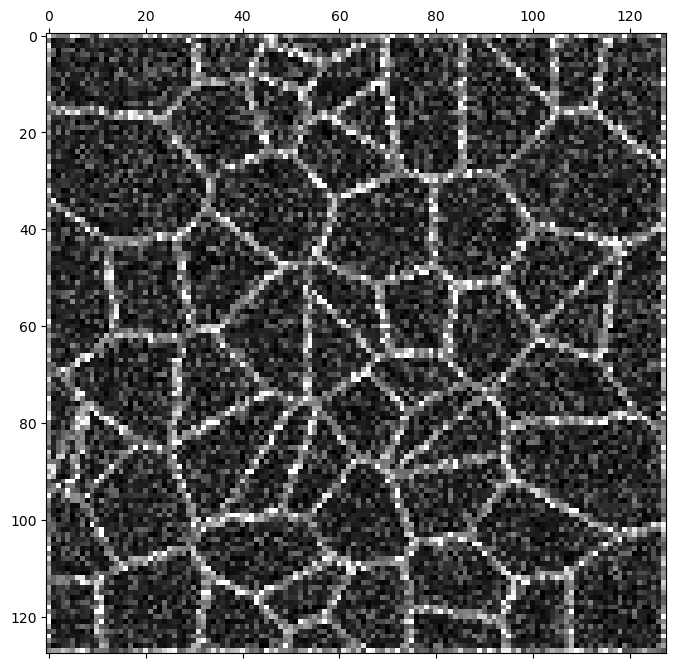

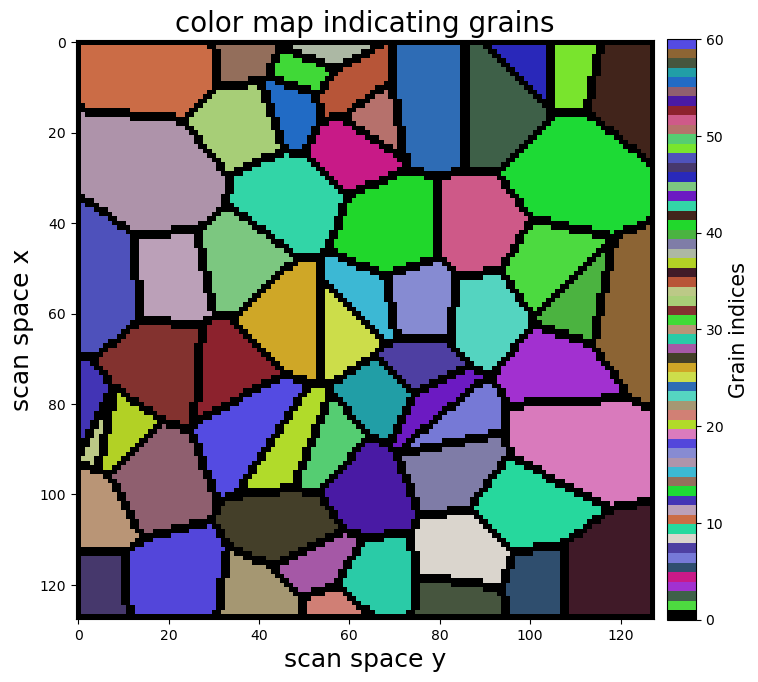

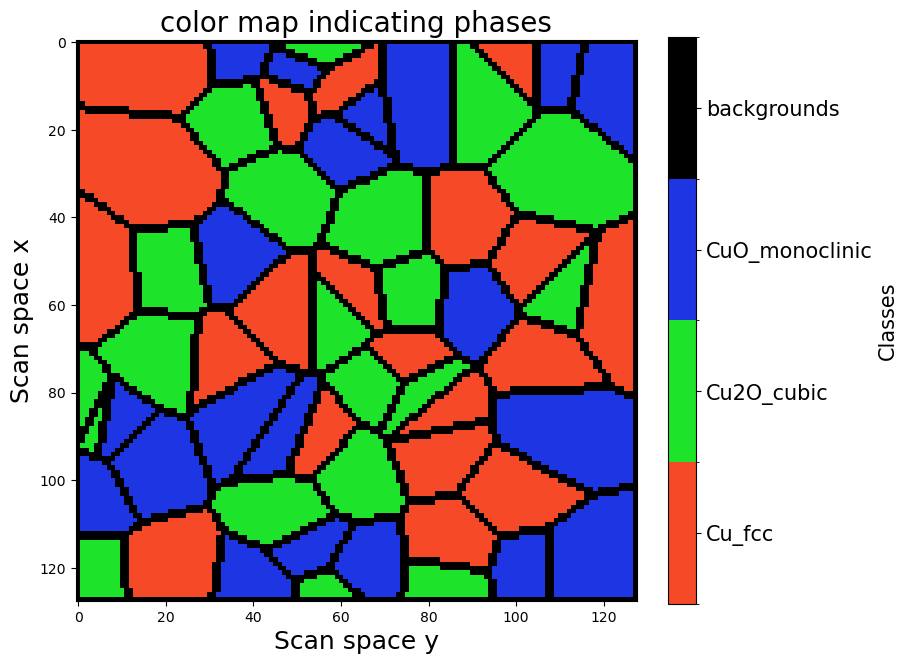

In [57]:

datacube_aligned_data.position_detector(
     data = dp_max,
#     data = datacube[10,30],
    mode = 'circle',
    geometry = (
        center,
        radius
    ),
)
datacube_aligned_data.get_virtual_image(
    mode = 'circle',
    geometry = (center,radius),
    name = 'bright_field',       # the output will be stored in `datacube`'s tree with this name
)
plt.close()
# show
print("\n\n\n\n\n\n\n")

print("virtual bright field")

fig,ax = show( datacube_aligned_data.tree('bright_field'), returnfig=True, figsize=(8, 9), scalebar = False )
fig.savefig("synthetic_4D_STEM_bright_field.png", bbox_inches='tight')

print("\n\n\n\n\n\n\n")
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.set_title("color map indicating grains", fontsize=20)
im = ax.imshow(syn_2D_scanSpace_map,  cmap =  custom_cmap)
ax.set_xlabel("scan space y", fontsize = 18)
ax.set_ylabel("scan space x", fontsize = 18)
cbar = plt.colorbar(im, ax = ax, fraction=0.0468, pad=0.02)
cbar.set_label("Grain indices", fontsize=15)
plt.savefig("grain_color_map.pdf", bbox_inches='tight')
plt.savefig("grain_color_map.png", bbox_inches='tight')
plt.show()
plt.close()



class_labels = ['Cu_fcc', 'Cu2O_cubic', 'CuO_monoclinic', 'backgrounds']
tick_positions = [0.5, 1.5, 2.5, 3.5]

# Set custom ticks and labels



fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.set_title("color map indicating phases", fontsize=20)
im = ax.imshow(class_label, cmap=phase_class_color_map, norm=phase_class_color_norm)
# Set axis labels
ax.set_xlabel("Scan space y", fontsize=18)
ax.set_ylabel("Scan space x", fontsize=18)
# Add the colorbar with custom ticks and labels
cbar = fig.colorbar(im, ax=ax, fraction=0.0457, ticks=phase_class_color_bounds)
# Set custom ticks and labels on the colorbar
cbar.set_ticks(tick_positions)
cbar.set_ticklabels(class_labels, fontsize=15)
cbar.set_label("Classes", fontsize=15)
plt.savefig("phase_color_map.pdf", bbox_inches='tight')
plt.savefig("phase_color_map.png", bbox_inches='tight')
plt.show()


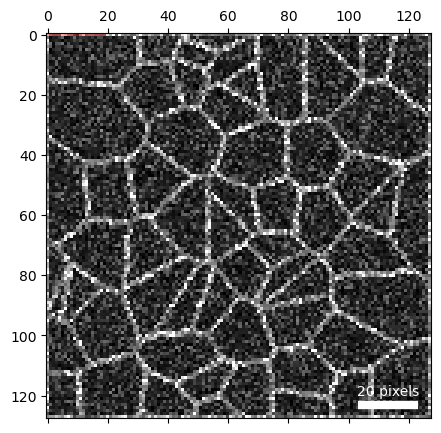

In [8]:
mask = np.zeros(datacube_aligned_data.Rshape,dtype=bool)
mask[0:1,0:20] = 1


show(
    datacube_aligned_data.tree('bright_field'),
    mask = ~mask,
    mask_alpha = 0.667,
    mask_color = 'r'
)

100%|██████████████████████████████████████████| 19/19 [00:00<00:00, 333.98it/s]


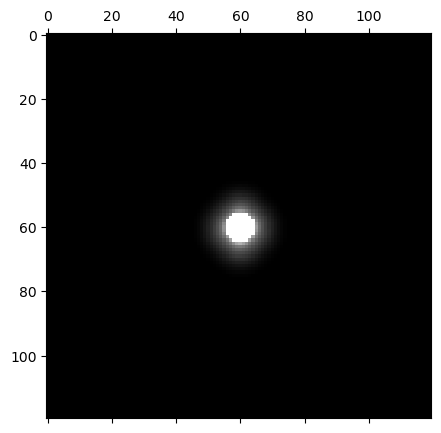

In [9]:
probe = datacube_aligned_data.get_vacuum_probe( ROI=mask )

show(
    probe.probe,
    scaling='none',
    intensity_range='absolute',
    vmin=0,
    vmax=1e5
)

alpha_pr_b,qx0_pr,qy0_pr 2.7520484219924692 60.109074285930575 59.93204659884352


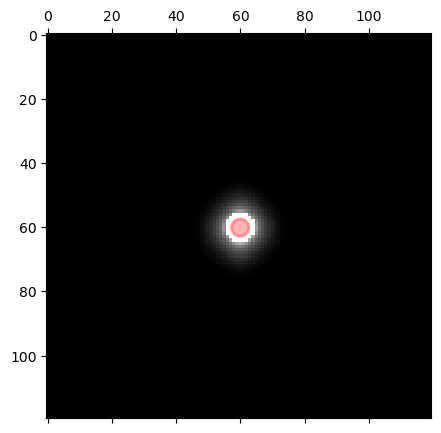

In [10]:

alpha_pr_b,qx0_pr,qy0_pr = datacube_aligned_data.get_probe_size( probe.probe )

print("alpha_pr_b,qx0_pr,qy0_pr", alpha_pr_b,qx0_pr,qy0_pr)


show(
    probe.probe, 
    scaling='none',
    intensity_range='absolute',
    vmin=0,vmax=1e5,
    circle = {
      'center':(qx0_pr,qy0_pr),
      'R': alpha_pr_b,
      'alpha':0.3,
      'fill':True
    }
)

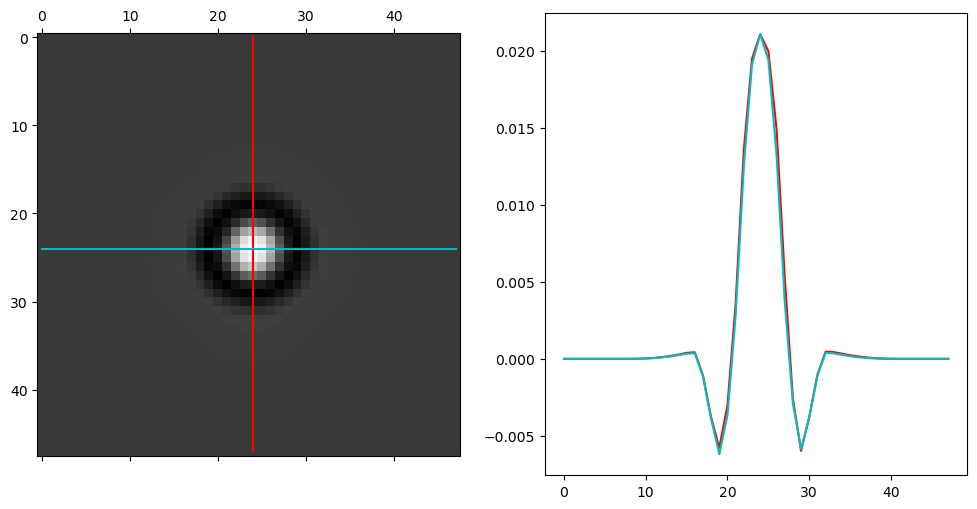

In [11]:
alpha_pr = alpha_pr_b * 1.5
probe.get_kernel(
    mode='sigmoid',
    origin=(qx0_pr,qy0_pr),
    radii=(alpha_pr, 2 * alpha_pr)   # the inner and outer radii of the 'trench'
)

py4DSTEM.visualize.show_kernel(
    probe.kernel,
    R = 24,
    L = 24,
    W = 1
)

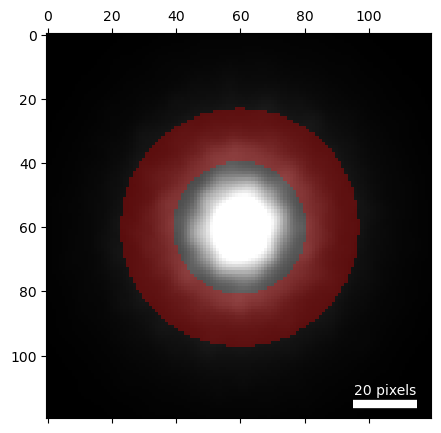

In [12]:

# set the geometry
center = qx0_pr,qy0_pr
r_inner = alpha_pr * 5
r_outer = alpha_pr * 9
radii = r_inner,r_outer

# overlay selected detector position over mean dp
datacube_aligned_data.position_detector(
    mode = 'annular',
    geometry = (
        center,
        radii
    )
)


100%|██████████████████████████████████| 16384/16384 [00:00<00:00, 51530.85it/s]


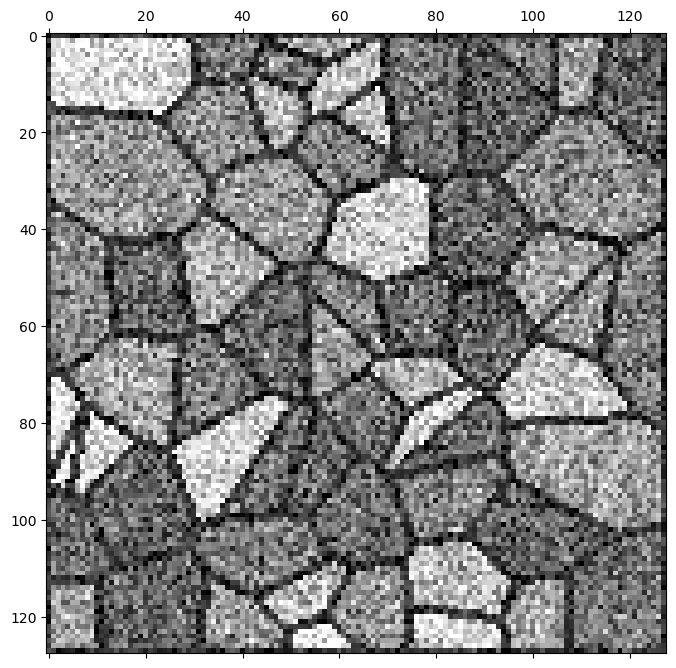

In [13]:
# compute
datacube_aligned_data.get_virtual_image(
    mode = 'annulus',
    geometry = (center,radii),
    name = 'annular_dark_field'
)

# show
fig, ax = show(datacube_aligned_data.tree('annular_dark_field'), returnfig=True, figsize=(8, 9), scalebar = False )
fig.savefig("synthetic_4D_STEM_dark_field.png", bbox_inches='tight')

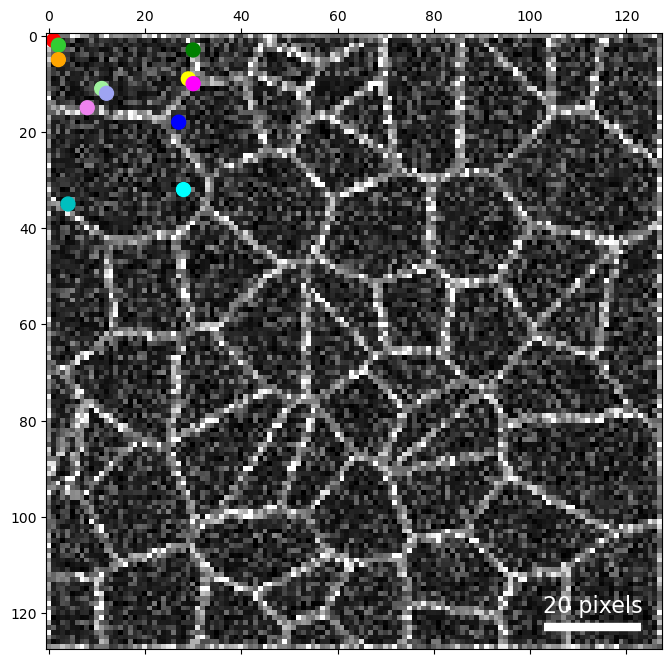

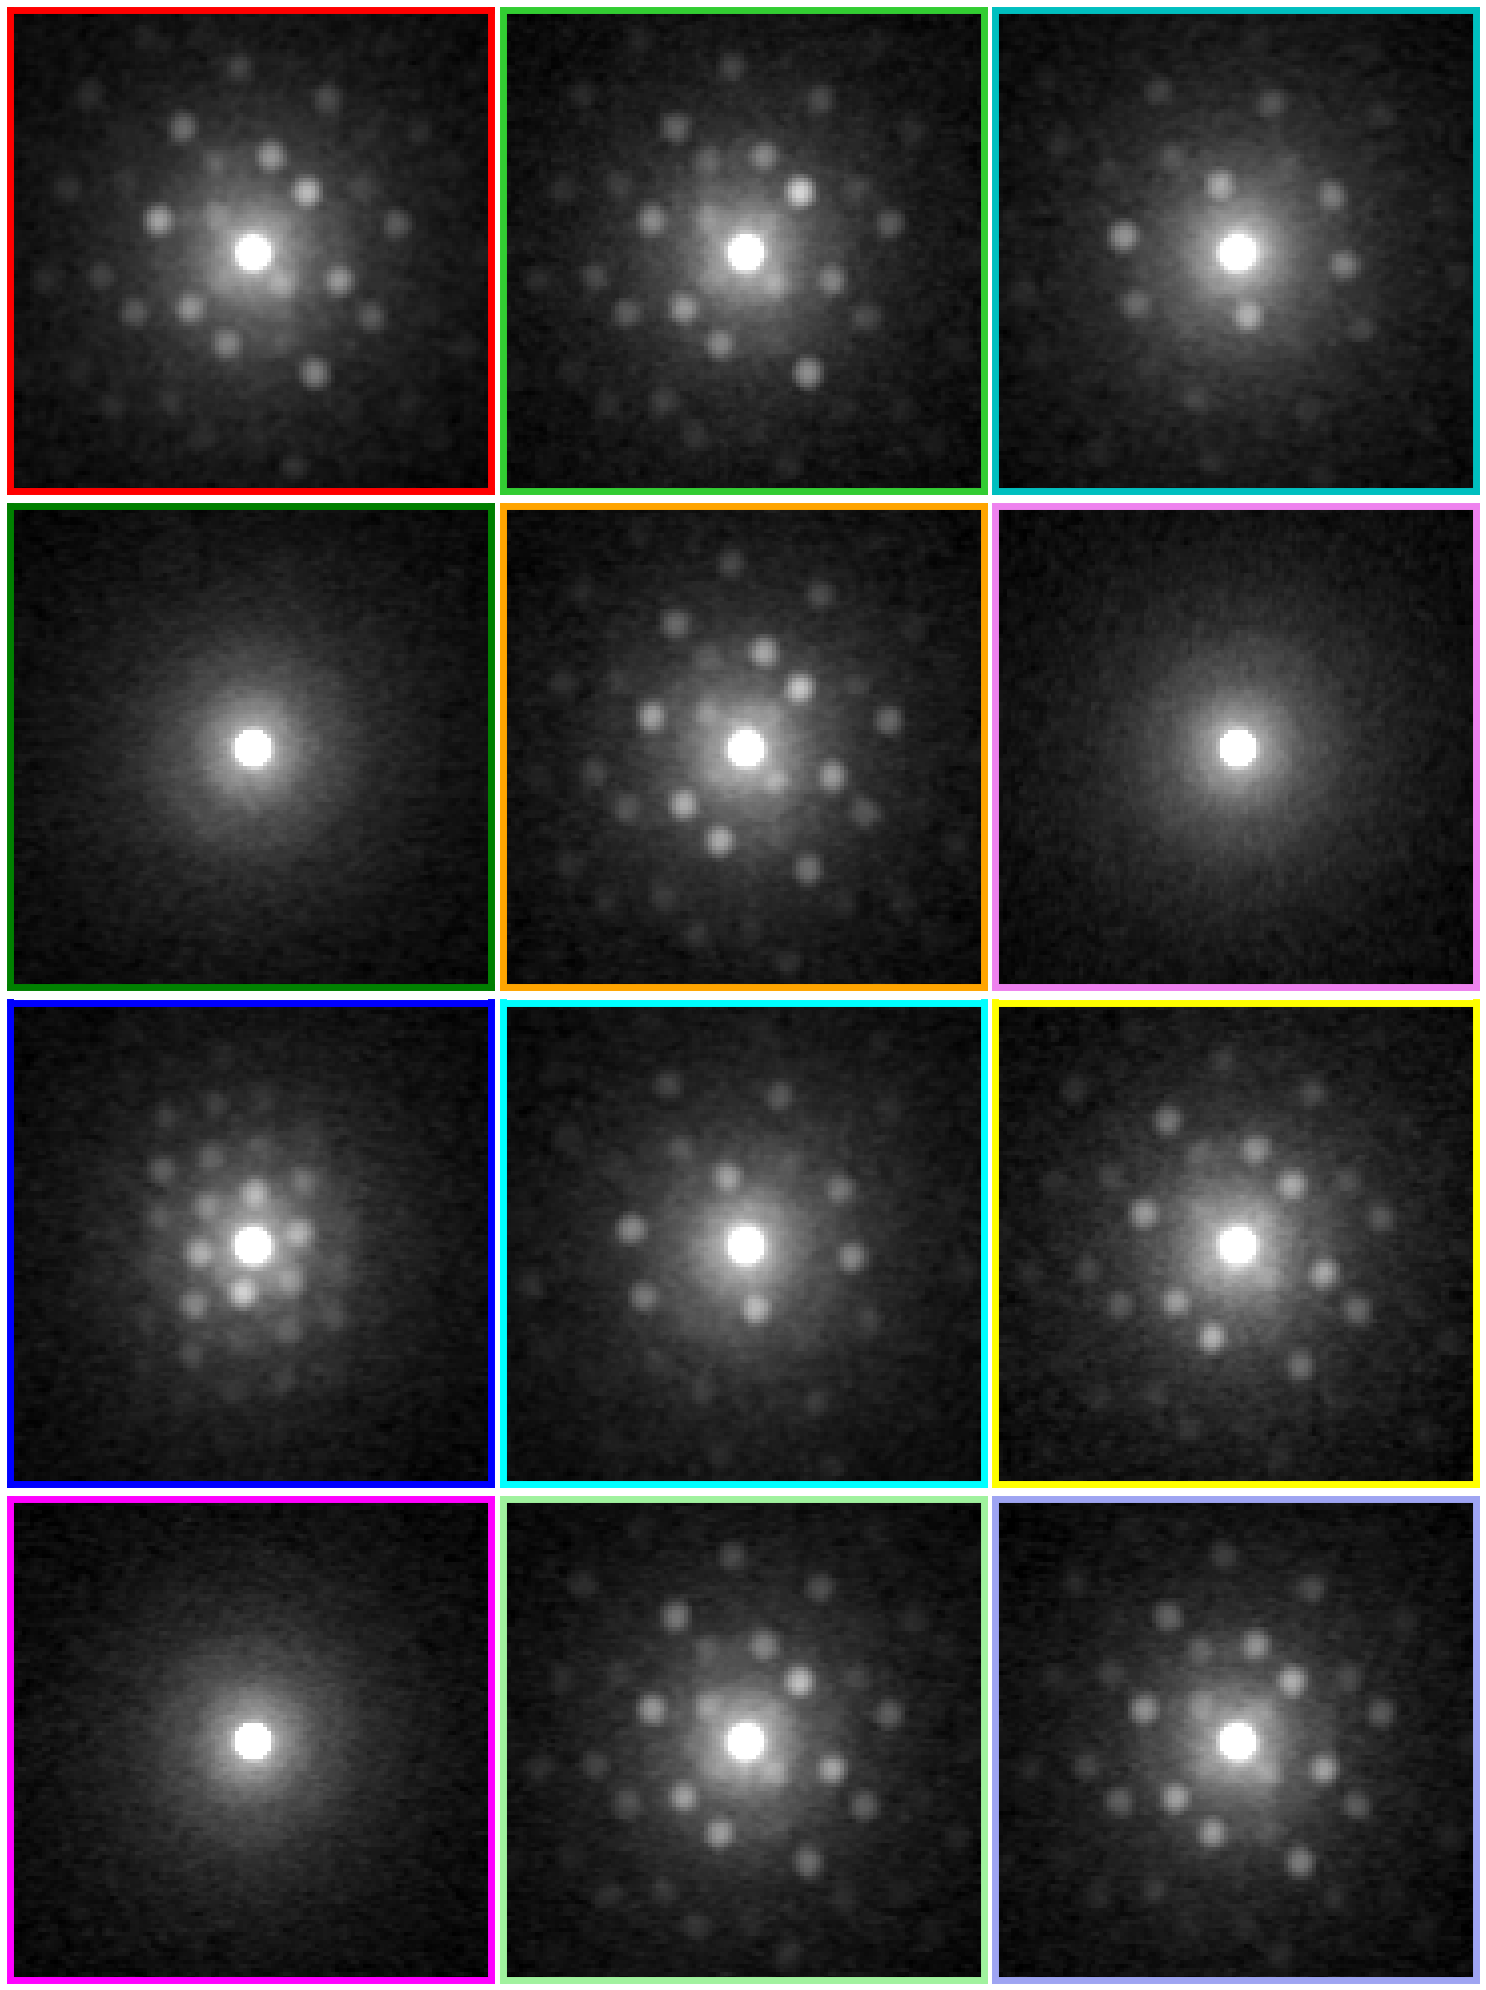

In [14]:
# rxs = 35,15,11,59,32,34,25,247, 122
# rys = 7,15,31,39,20,68,48,50, 131

rxs = 1,2,35,3,5,15, 18,32,9,10, 11, 12
rys = 1,2,4,30,2,  8, 27,28,29,30, 11, 12

# visualize

colors=['r','limegreen','c','g','orange', 'violet', '#0000ff', '#00ffff', '#ffff00', '#ff00ff', '#a0f29e', '#9ea4f2']

# show the selected
# positions in real space
py4DSTEM.visualize.show_points(
    datacube_aligned_data.tree('bright_field'),
    x=rxs,
    y=rys,
    scale = 100,
    pointcolor=colors,
    figsize=(8,8)
)

# show the selected
# diffraction patterns
py4DSTEM.visualize.show_image_grid(
    get_ar = lambda i:datacube_aligned_data[rxs[i],rys[i],:,:],
    H=4,W=3,
    axsize=(5,5),
    intensity_range='absolute',
    vmin=10,
    vmax=1e5,
    scaling='power',
    power=0.5,
    get_bordercolor = lambda i:colors[i],
)

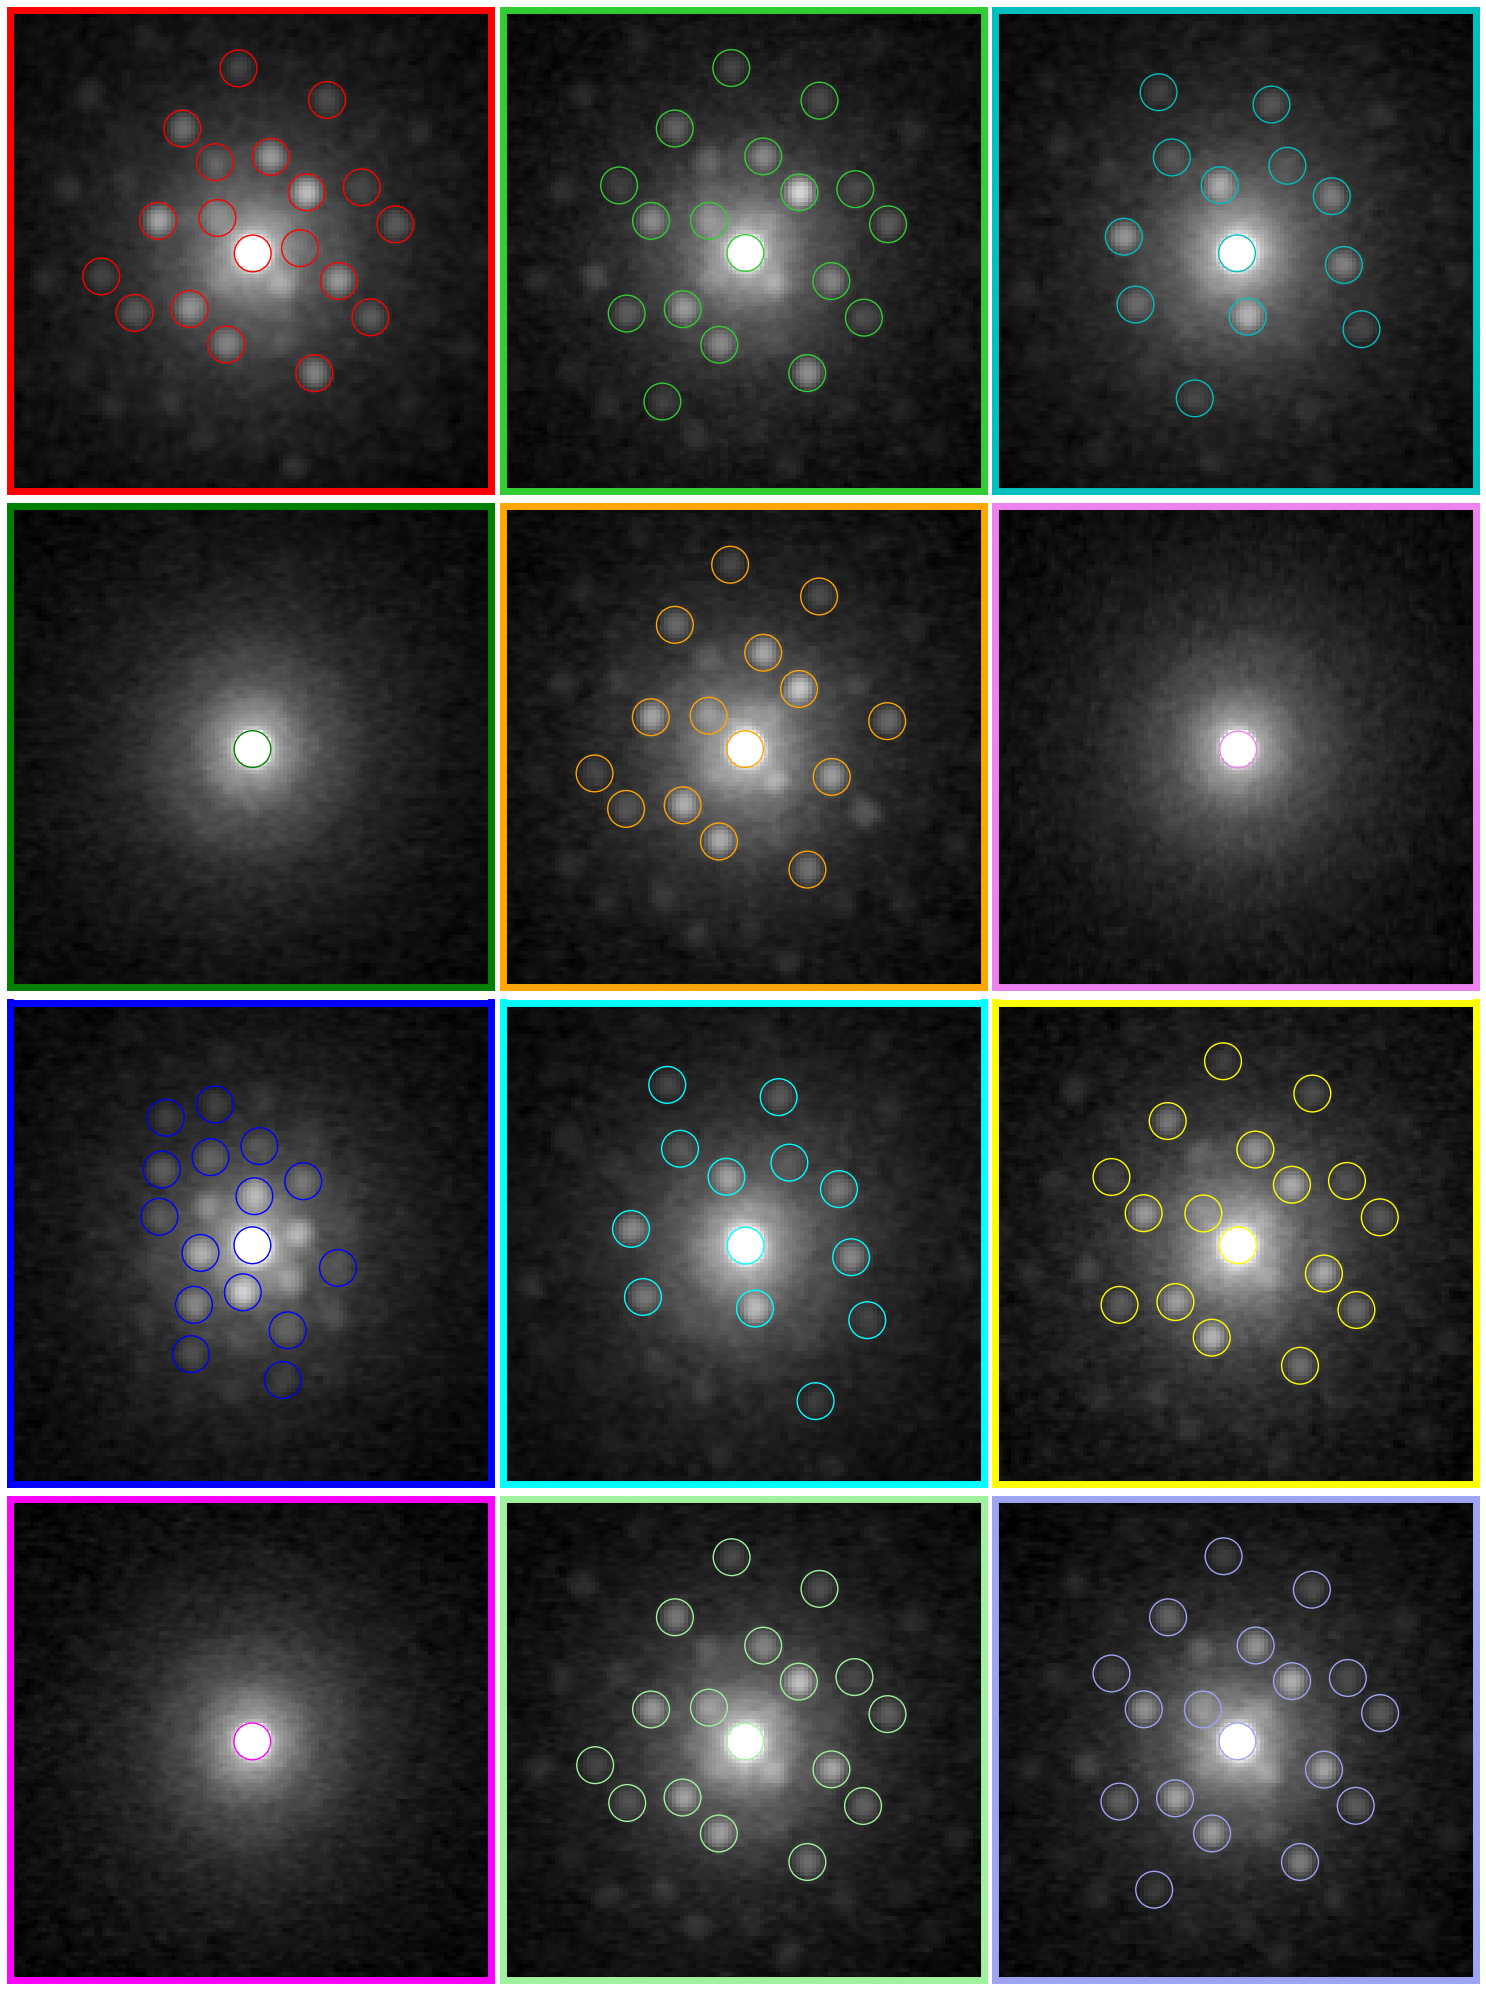

In [15]:

detect_params = {
    'minAbsoluteIntensity':950,   # intensity threshold
    'minRelativeIntensity': 0.0,   # int. thresh. relative to brightest disk in each pattern
    'minPeakSpacing': 12,         # if two peaks are closer than this (in pixels), remove the dimmer peak
    'edgeBoundary': 8,           # remove peaks within this distance of the edge of the diffraction pattern
    'sigma': 0.1,                  # gaussian blur size to apply to cross correlation before finding maxima
    'maxNumPeaks': 100,          # maximum number of peaks to return, in order of intensity
    'subpixel' : 'poly',         # subpixel resolution method
    'corrPower': 1.0,            # if <1.0, performs a hybrid cross/phase correlation. More sensitive to edges and to noise
#     'CUDA': True,              # if a GPU is configured and cuda dependencies are installed, speeds up calculation 
}


# find disks for selected patterns
disks_selected = datacube_aligned_data.find_Bragg_disks(
    data = (rxs, rys),
    template = probe.kernel,
    **detect_params,
)

# show
py4DSTEM.visualize.show_image_grid(
    get_ar = lambda i:datacube_aligned_data[rxs[i],rys[i],:,:],
    H=4, 
    W=3,
    axsize=(5,5),
    intensity_range='absolute',
    vmin=10,
    vmax=1e5,
    scaling='power',
    power=0.5,
    get_bordercolor = lambda i:colors[i],
    get_x = lambda i: disks_selected[i].data['qx'],
    get_y = lambda i: disks_selected[i].data['qy'],
    get_pointcolors = lambda i: colors[i],
    open_circles = True,
    scale = 700,
)
